In [146]:
import numpy as np
import matplotlib.pyplot as plt
import re

Extracting Dineutron Data:

In [147]:
# import os
# print("current working directory:", os.getcwd())
# os.chdir("C:\\Users\\shing\\OneDrive\\EinR + ResearchPaper\\fake_data")
# print("files here:", os.listdir())


In [148]:
# import h5py, numpy as np, matplotlib.pyplot as plt
# filename = "nn_swave_virtual_spectrum.h5"
# L = 6.0
# by_Psq = {}

# with h5py.File(filename, "r") as f:
#     mN = np.array([1.0]*5001)

#     for gname, g in f.items():
#         if gname == "mN":
#             continue
#         q1 = g["Psq_N1"][()][0]
#         q2 = g["Psq_N2"][()][0]
#         by_Psq.setdefault(q1, []).append(g["E_N1"][()])
#         by_Psq.setdefault(q2, []).append(g["E_N2"][()])

# Psq = np.array(sorted(by_Psq))
# p2 = (2*np.pi/L)**2 * Psq
# E = np.array([np.mean(by_Psq[q], axis=0) for q in Psq])
# print(Psq)
# print(p2)
# print(E.shape)

In [149]:
# import h5py
# import numpy as np
# import matplotlib.pyplot as plt
# import re

# rng = np.random.default_rng(1234)

# L = 6.0
 
# punit = 2*np.pi/L
# punit2 = punit**2


# def boot_err(x):
#     return np.std(x[1:], ddof=1)


# def get_dE(g):
#     for key in ["dE_NN", "dE", "DeltaE", "E0", "dE0"]:
#         if key in g:
#             return np.array(g[key])
#     raise KeyError(f"No energy shift found. Keys are {list(g.keys())}")


# def get_irrep(name):
#     return name.split("_Psq")[0]


# def get_Psq_total(name):
#     m = re.search(r"Psq(\d+)", name)
#     if m is None:
#         raise ValueError(f"Could not read total Psq from {name}")
#     return int(m.group(1))


# def get_level(name):
#     m = re.search(r"level(\d+)", name)
#     return int(m.group(1)) if m is not None else 0


# def dvec_from_d2(d2):
#     nmax = int(np.ceil(np.sqrt(max(d2, 1)))) + 2
#     best = None
#     for nx in range(nmax + 1):
#         for ny in range(nmax + 1):
#             for nz in range(nmax + 1):
#                 v = np.array([nx, ny, nz], dtype=int)
#                 if int(np.dot(v, v)) == int(d2):
#                     cand = tuple(sorted(v))
#                     if best is None or cand < best:
#                         best = cand
#     if best is None:
#         raise ValueError(f"No integer momentum representative found for Psq={d2}")
#     return np.array(best, dtype=int)


# raw_levels = []

# with h5py.File(filename, "r") as f:
#     mN = np.array([1.0]*5001)
#     m = float(mN[0])

#     for name, g in f.items():
#         if name == "mN":
#             continue

#         irrep = get_irrep(name)
#         Psq_tot = get_Psq_total(name)
#         level_index = get_level(name)

#         N1 = int(np.array(g["Psq_N1"])[0])
#         N2 = int(np.array(g["Psq_N2"])[0])
#         dE = get_dE(g)

#         E1 = np.sqrt(mN**2 + punit2*N1)
#         E2 = np.sqrt(mN**2 + punit2*N2)
#         E_NN = dE + E1 + E2

#         E_cm = np.sqrt(E_NN**2 - punit2*Psq_tot)
#         kstar2 = E_cm**2/4 - mN**2
#         # q2 = kstar2/punit2
#         q2 = kstar2


#         raw_levels.append({
#             "name": name,
#             "irrep": irrep,
#             "Psq_tot": Psq_tot,
#             "level_index": level_index,
#             "pair": tuple(sorted((N1, N2))),
#             "Ecm_boot": E_cm,
#             "q2_boot": q2,
#         })

# raw_levels = sorted(raw_levels, key=lambda r: (r["Psq_tot"], r["irrep"], r["level_index"], r["name"]))
# print([r["Psq_tot"] for r in raw_levels])

# print([r["irrep"] for r in raw_levels])
# #range: lowest level and highest level, and add/subtract .05 in q^2/m^2 units
# #.01 in q^2 units
# print(mN)

In [150]:
# Energy_list = []
# for r in raw_levels:
#     Energy_list.append(r['Ecm_boot'][0])



# Ecm_boot = []

# # 1. Keep the single number r['Ecm_boot'] as it is (no slicing needed)
# Ecm_boot = [[r['name'], r['Ecm_boot'][0]] for r in raw_levels]

# # 2. Sort directly by that number (x[1] targets the Ecm_boot value)
# Ecm_boot.sort(key=lambda x: x[1])

# print(*Ecm_boot, sep='\n')

# # sorted_indices = np.argsort(Ecm_boot[:, 0])
# # Eboot = Ecm_boot[sorted_indices]



F-Function

In [151]:
import itertools
from scipy import special as sp

'''
Finite-volume function
'''

twoPi = 2.0 * np.pi


# Let us work with ideentical particles throughout
xi = 0.5 # symmetry factor

# sqrt with branch cut aligned on positive real axis
def mySqrt(z):
   return 1j * np.sqrt( -z )

# CM momentum
def q_cm(s):
    return 0.5 * mySqrt( s - 4.0 * float(m) **2 )

# Phase space factor
def phase_space(s):
    return xi * q_cm(s) / ( 8.0 * np.pi * np.sqrt(s) )

# inner product for two list (native)
def dot(A, B):
   return np.dot(A,B) #inner1d(A,B) #np.sum( A * B, axis=1)


def inner1d(A, B):
   return np.sum( A * B, axis=1)


# Function to generate 3-tuple "n = (nx,ny,nz)" list
# subject to the constraint nx^2 + ny^2 + nz^2 <= nShell^2,
# where "nShell" indicates the number of shells
def generateIntList( nShell ):
    intList = []
    rawList = np.array(np.arange(-nShell,nShell+1))
    for i in itertools.product(rawList,rawList,rawList):
        tmpList = np.array(i)
        if ( np.dot(tmpList,tmpList) <= nShell*nShell ):
            intList.append(tmpList)

    return np.asarray(intList)

# returns the unit vector of a vector "A"
def unit_vector( A ):
    if( all( A==0 ) ):
        return A
    else:
        return A / np.sqrt( np.dot(A,A) )

# special multiply for array of arrays (A) and an array (B), used in the zeta function
def multiply( A, B ):
   nA = len(A)
   return A.reshape(nA,1) * np.tile( B, (nA,1) )
   ### First, reshape A array to 2d (1xnA), and then copy b vector nA time to make (nA x nB) array
   ### alternatively, do (A.reshape(nA,1)).dot( B.reshape(1,3) )

# returns a Lorentz boosted four vector "(A0,A)" given some boost velocity "beta"
def lorentzBoost( A0, A, beta ):
    gamma = 1.0 / np.sqrt( 1.0 - np.dot(beta,beta) )
    Apar  = multiply( A.dot( unit_vector(beta) ), unit_vector(beta) )
    Aper  = A - Apar
    A0_prime = gamma * ( A0 - A.dot( beta ) )
    A_prime  = gamma * ( Apar - multiply( A0, beta ) ) + Aper
    return A0_prime, A_prime


# cutoff function (alpha input is dimensionless)
def cutoff( qcm_sq, kcm_sq, alpha, L ):
    alpha = (L / twoPi)**2 * alpha  # convert to dimensionfull units
    return np.exp( -alpha * ( kcm_sq - qcm_sq ) )

#
# KSS Zeta function for ell = m_ell = 0, given "qcm_sq", total momentum "nP"
# This function is in units of L / 2pi, e.g. m1 -> m1 * L / (2 * pi).
#

# Finite volume function F, given Ecm (units of mass), nP, alpha (dimensionless), and L (units of mass)
# MUST call generateIntList first and use global intList from its output
#
# Note: We chose to have Ecm as input rather than E for convenience in plotting/ pole finding. Coding it the other way works too,
# we are just saving ourselves a couple transformations which are not needed for our purposes.
#
def F_function( Ecm, nP, alpha, L):
    P = twoPi * nP / L                               # P = (2*pi/L)* nP
    P_sq = np.dot(P,P)                              # P^2
    E = np.sqrt( Ecm**2 + P_sq )                    # compute E given Ecm and P
    s = Ecm**2
    eps = 1e-16
    qcm = q_cm(s+1j*eps)
    qcm_sq = qcm**2
    rho = phase_space(s+1j*eps)
    beta = P/E                                      # boost velocity

    m_sq = m**2

    k = (twoPi / L) * intList
    omega = np.sqrt( m_sq + inner1d(k,k) )
    omega_cm, k_cm = lorentzBoost( omega, k, beta )
    tmp = cutoff( qcm_sq, inner1d(k_cm,k_cm), alpha, L ) * omega_cm / omega
    tmp = tmp / ( qcm_sq - inner1d(k_cm,k_cm ) )
    sum0 = ( xi / (2.0 * Ecm * L**3) ) * np.sum( tmp )

    alpha = (L / twoPi)**2 * alpha  # convert to dimensionfull units
    z   = np.sqrt( alpha ) * qcm
    integral = ( xi / (4.0 * np.pi**2 * Ecm )) * ( ( np.sqrt( 0.25 * np.pi / alpha ) ) * np.exp( alpha * qcm_sq ) - 0.5 * np.pi * qcm * sp.erfi( z ) )

    return  1j * rho + sum0.real + integral # taking real part of sum to remove imaginary artifact at threshold



Various Constants

In [152]:
nShell = 15
alpha = 0.125

intList = generateIntList( nShell )

pole_gap = 2e-4
m =1.0
#m_pi = 0.310810

Psq_to_nP = {
    0:np.array([0,0,0]),
    1:np.array([0,0,1]),
    2:np.array([0,1,1]),
    3:np.array([1,1,1]),
    4:np.array([0,0,2])
}

# present_Psq = sorted(set(lvl["Psq_tot"] for lvl in raw_levels))
# Psq_to_nP = {psq: dvec_from_d2(psq) for psq in present_Psq}

L_values = [6]

# E_min = np.min(Energy_list)-0.1
# E_max = np.max(Energy_list)+0.1

E_min,E_max = 1.85,2.50

q2_min = ((E_min/2)**2 - m**2)
q2_max = ((E_max/2)**2 - m**2)
q_star_sq_grid = np.linspace(q2_min , q2_max ,2500)

Ecm_grid = 2*np.sqrt(q_star_sq_grid + m**2)


a_r_Values = np.array([
    [-5.50,-0.034,0.0],  # virtual state  -> matches Fig. 3
    [-0.18,0.32,0.05],     # virtual state  -> matches Fig. 3                             
    [ 0.18,0.0,0.0],   # shallow bound state -> matches Fig. 5
    [1.0,1.0,0.0],
    [2.0,0,0.0],
])
print(E_min,E_max)
print(q2_min,q2_max)

1.85 2.5
-0.14437499999999992 0.5625


Fake Energy Levels 

In [153]:
pole_cache = {}


def free_particle_poles(nP, L, m, E_min, E_max, maxShell=15):
    punit_ = 2*np.pi/L
    nP_arr = np.array(nP, dtype=float)
    Pvec = punit_*nP_arr
    P2_ = np.dot(Pvec, Pvec)
    levels = []
    for i in range(-maxShell, maxShell+1):
        for j in range(-maxShell, maxShell+1):
            for k in range(-maxShell, maxShell+1):
                n1 = np.array([i,j,k]); n2 = nP_arr - n1
                p1, p2 = punit_*n1, punit_*n2
                E_lab = float(np.sqrt(p1@p1+m**2) + np.sqrt(p2@p2+m**2))
                E_cm_sq = E_lab**2 - P2_
                if E_cm_sq <= 0:
                    continue
                E_cm = np.sqrt(E_cm_sq)
                if E_min - 0.05 < E_cm < E_max + 0.05:
                    levels.append(E_cm)
    return np.unique(np.round(levels, 10))


def free_particle_poles_cached(nP, L, m, E_min, E_max, maxShell=15):
    key = (tuple(nP), L, m, E_min, E_max, maxShell)
    if key not in pole_cache:
        raw = free_particle_poles(nP, L, m, E_min, E_max, maxShell)

        if len(raw) == 0:
            pole_cache[key] = raw
        else:
            unique = [raw[0]]
            for p in raw[1:]:
                if abs(p - unique[-1]) > 1e-5:
                    unique.append(p)
            pole_cache[key] = np.array(unique, dtype=float)
    return pole_cache[key]



In [154]:
def mySqrt_vectorized(z):
    z = np.asarray(z, dtype=complex)
    return 1j * np.sqrt(-z)

def q_cm_vectorized(s):
    return 0.5 * mySqrt_vectorized(s - 4.0 * m**2)

def M_using_a_r(Ecm, a, r, p4):
    s = Ecm**2
    qcm = q_cm_vectorized(s)
    # effective_range = -1/a + 0.5* r * (qcm**2) + p4 * (qcm**4)
    effective_range = -1/a + 0.5*r * (qcm**2) + p4 * (qcm**4)
    return (8.0 * np.pi * np.sqrt(s)) / (xi * (effective_range - (1j * qcm)))

# def M_using_a_r(Ecm, a, r): 
#     s = Ecm**2
#     qcm = q_cm_vectorized(s)
#     effective_range = (-1/a) + 0.5 * r * (qcm**2)
#     return (8.0 * np.pi * np.sqrt(s)) / (xi * (effective_range - (1j * qcm)))

# def quantization_condition(Ecm, a, r, nP,L):
#     # eps = 1e-16
#     # s = Ecm**2 + 1j*eps
#     # qCotDelta = -1/a + 0.5*r*q_cm(s)**2
#     # Kinverse = xi * qCotDelta / (8*np.pi*Ecm)   <----- 2 ways to implment quantization condition. Comment out 1
#     # Fpv = F_function(Ecm, nP, alpha, L).real   
#     # return (Kinverse + Fpv).real
   
   
#     FValues = F_function(Ecm,nP,alpha,L)
#     MValues = M_using_a_r(Ecm,a,r)                 #<----- 2 ways to implment quantization condition. Comment out 1
#     return np.real(1/MValues + FValues)

In [155]:


# def find_zeros_in_grid(quantization_values, energies, poles,Psq):
#     zeros = []
#     for i in range(len(energies) - 1):
#         f1, f2 = quantization_values[i], quantization_values[i+1]
#         e1, e2 = energies[i], energies[i+1]
#         if not (np.isfinite(f1) and np.isfinite(f2)):
#             continue
#         if np.sign(f1) == np.sign(f2):
#             continue
#         if np.any((poles >= e1) & (poles <= e2)):
#             continue   
#         slope = (f2 - f1) / (e2 - e1)

#         root = e1 - f1/slope
#         if np.any(np.abs(root - poles) < pole_gap):
#             continue


#         zeros.append(e1 - f1/slope)
    # return np.array(zeros)

def find_zeros_in_grid(quantization_values, energies, poles, Psq):
    f1, f2 = quantization_values[:-1], quantization_values[1:]
    e1, e2 = energies[:-1], energies[1:]

    mask = np.isfinite(f1) & np.isfinite(f2) & (np.sign(f1) != np.sign(f2))

    if len(poles) > 0 and mask.any():
        idxs = np.where(mask)[0]
        bracket_has_pole = np.zeros(len(idxs), dtype=bool)
        for p in poles:                       # loop over poles (small, ~5-15), not grid points
            bracket_has_pole |= (p >= e1[idxs]) & (p <= e2[idxs])
        mask[idxs] &= ~bracket_has_pole

    idx = np.where(mask)[0]
    if len(idx) == 0:
        return np.array([])

    slope = (f2[idx] - f1[idx]) / (e2[idx] - e1[idx])
    roots = e1[idx] - f1[idx]/slope

    if len(poles) > 0 and len(roots) > 0:
        dists = np.abs(roots[:, None] - poles[None, :])
        keep = np.all(dists >= pole_gap, axis=1)
        roots = roots[keep]

    return roots


In [156]:
F_by_Psq = {}
for L in L_values:
    for Psq_tot, nP in Psq_to_nP.items():
        F_by_Psq[(L, Psq_tot)] = np.array([
            F_function(Ecm, nP, alpha, L) for Ecm in Ecm_grid
        ])

#test code, not ever used
# def spectrum_from_ar(a, r, L, Psq_tot):
#     Q = quantization_grid(a, r, L, Psq_tot)
#     poles = free_particle_poles_cached(Psq_to_nP[Psq_tot], L, m)
#     return find_zeros_in_grid(Q, Ecm_grid, poles, Psq_tot)

def quantization_grid(a, r, p4, L, Psq_tot):
    M_values = M_using_a_r(Ecm_grid, a, r, p4)
    F_values = F_by_Psq[(L, Psq_tot)]
    return np.real(1.0 / M_values + F_values)

In [157]:

sigma_E = 1.4e-3 #the uncertainty, acts as noise
rng = np.random.default_rng()


# def generate_spectrum(i, L_values, Psq_to_nP, E_min, E_max, sigma_E):
#     rows = [] #the "observed" data, is noisy
#     true_rows = [] #the actual data values, to check with.only exists for valdiation
#     a,r = a_r_Values[i]

#     for L in L_values:
#         for Psq, nP in Psq_to_nP.items():
#             Q = quantization_grid(a, r, L, Psq)
#             poles = free_particle_poles_cached(nP, L, m, E_min, E_max)
#             E_true_levels = find_zeros_in_grid(Q, Ecm_grid, poles, Psq)

#             for level_index, E_true in enumerate(E_true_levels):
#                 E_obs = E_true + rng.normal(0.0, sigma_E)       
#                 row = {
#                     "L": float(L),
#                     "Psq": Psq,
#                     "level_index": level_index,
#                     "E_true": float(E_true),
#                     "E_obs": float(E_obs),
#                     "dE": sigma_E,
#                 }

#                 rows.append(row)
#                 true_rows.append(row.copy())

#     data = rows
#     print(f"generated {len(data)} finite-volume levels across {len(L_values)} volumes and {len(Psq_to_nP.keys())} frames")
#     return data 




In [158]:
def generate_spectrum_covariance(i, L_values, Psq_to_nP, E_min, E_max, sigma_E):
    rows = [] 
    a, r, p4 = a_r_Values[i] # Pick your a, r, p4 from a_r_Values based on index i

    for L in L_values:
        for Psq, nP in Psq_to_nP.items():
            Q = quantization_grid(a, r, p4, L, Psq)
            poles = free_particle_poles_cached(nP, L, m, E_min, E_max)
            E_true_levels = find_zeros_in_grid(Q, Ecm_grid, poles, Psq)

            for level_index, E_true in enumerate(E_true_levels):
                row = {
                    "L": float(L),
                    "Psq": Psq,
                    "level_index": level_index,
                    "E_true": float(E_true),
                }
                rows.append(row)
                
    Etrue = np.array([row["E_true"] for row in rows])
    num_bootstrap = 5000
    num_levels = len(Etrue)
    
    # Toy covariance settings
    sigma_true = np.linspace(0.006, 0.014, num_levels)
    rho = 0.6
    scale = rho**np.abs(np.subtract.outer(np.arange(num_levels), np.arange(num_levels)))
    covariance_matrix = np.outer(sigma_true, sigma_true) * scale

    # Generate correlated multivariate noise
    Eboot = rng.multivariate_normal(Etrue, covariance_matrix, size=num_bootstrap)
    Eobs = np.mean(Eboot, axis=0)

    for j, row in enumerate(rows):
        row["E_obs"] = float(Eobs[j])
        
        # Convert Energies to q*^2
        q2_obs = (Eobs[j] / 2)**2 - m**2
        q2_replicas = (Eboot[:, j] / 2)**2 - m**2
        
        # Pack them into the exact format your GPR pipeline expects: 
        # [central_value, replica_1, replica_2, ...]
        row["q2_boot"] = np.concatenate(([q2_obs], q2_replicas))
        
    print(f"Generated {len(rows)} finite-volume levels across {len(L_values)} volumes and {len(Psq_to_nP.keys())} frames")
    return rows 

# Generate your toy data using a specific index from a_r_Values (e.g., 0 for a=-5.5, r=-0.034)
toy_data = generate_spectrum_covariance(0, L_values, Psq_to_nP, E_min, E_max, sigma_E)

data0_cov = generate_spectrum_covariance(3, L_values, Psq_to_nP, E_min, E_max, sigma_E)
data1_cov = generate_spectrum_covariance(4, L_values, Psq_to_nP, E_min, E_max, sigma_E)



Generated 7 finite-volume levels across 1 volumes and 5 frames
Generated 4 finite-volume levels across 1 volumes and 5 frames
Generated 4 finite-volume levels across 1 volumes and 5 frames


In [159]:
Psq_offsets = {0: -0.2, 1: -0.1, 2: 0.0, 3: 0.1, 4: 0.2}

def plot_spectrum(level_rows, i, include_observed=True, include_true=False, predicted_rows=None):
    plt.figure(figsize=(10, 6))
    for Psq in Psq_to_nP.keys():
        offset = Psq_offsets[Psq]
        rows_frame = [r for r in level_rows if r["Psq"] == Psq]

        if include_observed:
            x_obs = np.array([r["L"] + offset for r in rows_frame], dtype=float)
            y_obs = np.array([r["E_obs"] for r in rows_frame], dtype=float)
            yerr = np.array([r["dE"] for r in rows_frame], dtype=float)

            plt.errorbar(
                x_obs,
                y_obs,
                yerr=yerr,
                fmt="o",
                markersize=6,
                capsize=5,
                capthick=1.8,
                elinewidth=1.8,
                linewidth=0,
                label=f"{Psq} observed",
                zorder=5,
            )

        if include_true:
            x_true = np.array([r["L"] + offset for r in rows_frame], dtype=float)
            y_true = np.array([r["E_true"] for r in rows_frame], dtype=float)

            plt.scatter(
                x_true,
                y_true,
                marker="_",
                s=180,
                linewidths=2.8,
                label=f"{Psq} true",
                zorder=4,
            )

    if predicted_rows is not None:
        for Psq in Psq_to_nP.keys():
            offset = Psq_offsets[Psq]
            rows_frame = [r for r in predicted_rows if r["Psq"] == Psq]
            x_pred = np.array([r["L"] + offset for r in rows_frame], dtype=float)
            y_pred = np.array([r["E_pred"] for r in rows_frame], dtype=float)

            plt.scatter(
                x_pred,
                y_pred,
                marker="x",
                s=70,
                linewidths=2.2,
                label=f"{Psq} GP",
                zorder=6,
            )

    # plt.xticks(L_values, [str(int(L)) for L in L_values])
    plt.xlabel(r"$L$")
    plt.ylabel(r"$E^*$")
    plt.title(f"Finite-volume spectrum, a={a_r_Values[i][0]}, r={a_r_Values[i][1]}")

    plt.legend(ncols=3, fontsize=8)
    plt.tight_layout()
    plt.show()


#plot_spectrum(data0, 0)
#plot_spectrum(data1, 1)
# plot_spectrum(data_real, 0)


Gaussian Process Regression 

Covariance Matrix


In [160]:
def build_covariance(levels, key="q2_boot"):
    boot_matrix = np.array([lvl[key][1:] for lvl in levels]).T   # (n_boot, n_levels)
    obs = np.array([lvl[key][0] for lvl in levels])
    cov = np.cov(boot_matrix, rowvar=False, ddof=0)
    return obs, cov

# q2_obs, covariance = build_covariance(raw_levels)
# cov_inv = np.linalg.inv(covariance)


In [161]:
def get_q_cot_delta(E,nP,alpha,L):
    F_pv = F_function(E, nP, alpha, L).real
    return -8 * np.pi * E * F_pv / xi


Building my own GP implementation 

Stage 1.
    - vector of knots
    - builds nxn kernel matrix, given hyperparamters
    - adds small jitter term

In [162]:
num_knots = 8 
knots = np.linspace(q2_min,q2_max,num_knots) # knots ->x

def RBC_kernel(x,y,sigma,length_scale): # kernel matrix 
    x=np.asarray(x).reshape(-1,1)
    y=np.asarray(y).reshape(-1,1)
    return sigma**2 * np.exp(-0.5 * (np.abs(x-y.T)**2) / length_scale**2)

def Matern_kernel(x, y, sigma, length_scale, nu=0.5):
    x = np.asarray(x).reshape(-1,1)
    y = np.asarray(y).reshape(-1,1)
    r = np.sqrt(np.abs(x - y.T))
    if nu == 0.5:
        return sigma**2 * np.exp(-r / length_scale)
    elif nu == 1.5:
        return sigma**2 * (1 + np.sqrt(3) * r / length_scale) * np.exp(-np.sqrt(3) * r / length_scale)
    elif nu == 2.5:
        return sigma**2 * (1 + np.sqrt(5) * r / length_scale + 5 * r**2 / (3 * length_scale**2)) * np.exp(-np.sqrt(5) * r / length_scale)


def kernel_matrix(x, y, sigma, length_scale, kernel_func = RBC_kernel):
    k =  kernel_func(y, y, sigma, length_scale) + np.eye(len(y)) * 1e-8 
    sign, logdet = np.linalg.slogdet(k)
    if sign <= 0:
        raise np.linalg.LinAlgError("GP covariance is not positive definite")

    K_inv = np.linalg.inv(k)
    interp_grid = kernel_func(x, y , sigma, length_scale) @ K_inv                        

    return k, K_inv, logdet, interp_grid



Stage 2.
    -

In [163]:
# def k_inv_Grid(Ecm, sigma, length_scale, f_values): #we are deliberately not using the covariance term
#     k, k_inv, logdet, interp_grid = kernel_matrix(knots,knots,sigma,length_scale)
#     k_inv_grid = interp_grid @ f_values
#     return k_inv_grid

def qCotDelta_Grid(x, sigma, length_scale,mu, f_values): #we are deliberately not using the covariance term
    k, k_inv, logdet, interp_grid = kernel_matrix(x,knots,sigma,length_scale)
    qCotDelta_Grid = mu + interp_grid @ (f_values-mu)
    return qCotDelta_Grid


Stage 3:
Using GP curve in place of ERE in Luscher Quantization Formula

In [164]:
rho_grid = np.array([phase_space(E**2 + 1j*1e-16) for E in Ecm_grid])  # same eps as F_function

F_pv_by_Psq = {key: np.real(Fvals - 1j*rho_grid)
               for key, Fvals in F_by_Psq.items()}

def find_Zeros_GPR(f_values, sigma, length_scale, L, Psq, qCotDelta_Grid):
    qcd_conversion = 8 *np.pi * Ecm_grid / xi
    Q = qCotDelta_Grid + (qcd_conversion*F_pv_by_Psq[(L, Psq)])
    poles = free_particle_poles_cached(Psq_to_nP[Psq], 6, m, E_min, E_max)
    return find_zeros_in_grid(Q, Ecm_grid, poles, Psq)

Stage 4

In [165]:
def build_observed_cache(data):
    """
    Group observed synthetic levels by (L, Psq) sector, once, so the
    likelihood function can look them up instantly on every MCMC call
    instead of re-filtering the full dataset each time.

    Returns:
        dict keyed by (L, Psq) -> {"E_obs": np.array, "dE": np.array}
    """
    cache = {}
    for row in data:
        key = (row["L"], row["Psq"])
        if key not in cache:
            cache[key] = {"E_obs": [], "dE": []}
        cache[key]["E_obs"].append(row["E_obs"])
        cache[key]["dE"].append(row["dE"])

    for key in cache:
        cache[key]["E_obs"] = np.array(cache[key]["E_obs"])
        cache[key]["dE"] = np.array(cache[key]["dE"])

    return cache


# observed_cache_0 = build_observed_cache(data0)   
# observed_cache_1 = build_observed_cache(data1)   

# observed_cache_0_cov = build_observed_cache(data0_cov)   # a=1, r=1
# observed_cache_1_cov = build_observed_cache(data1_cov)   # a=2, r=0

# observed_cache_real = build_observed_cache(data_real)



cov_epsilion = 1e-11
def build_observed_data(levels, L):
    """
    levels: list of dicts (raw_levels, or the 8 combined deuteron levels),
            each with 'Psq', 'level_index', and a 'q2_boot' bootstrap array
            (index 0 = central value, 1: = replicas).
    Returns a fixed-order channel dataset for use in log_likelihood.
    """
    obs, cov = build_covariance(levels, key="q2_boot")
    cov_reg = cov + np.eye(len(cov)) * cov_epsilion
    cov_inv = np.linalg.inv(cov_reg)
    
    # Extract the sector keys from the generated toy data
    sector_keys = [(lvl["Psq"], lvl["level_index"]) for lvl in levels]
    
    # Return the dictionary with 'sector_keys' included!
    return {"L": L, "sector_keys": sector_keys, "obs": obs, "cov_inv": cov_inv}, cov_reg

# observed_cache_dineutron,cov_reg_dineutron = build_observed_data(raw_levels,6)
# Pass your generated toy_data directly
observed_cache_fake_data, cov_reg = build_observed_data(toy_data, L=6)

def rows_from_combined_levels(Eboot_combined, Psq_combined, level_index_combined):
    """
    Eboot_combined: (n_groups, N_boot) bootstrap CM-energy matrix, index 0 = central value.
    Psq_combined: list of Psq_tot, one per group, in the same order as Eboot_combined's rows.
    """
    n_groups = Eboot_combined.shape[0]
    if level_index_combined is None:
        counts = {}
        level_index_combined = []
        for psq in Psq_combined:
            level_index_combined.append(counts.get(psq, 0))
            counts[psq] = counts.get(psq, 0) + 1

    levels = []
    for g in range(n_groups):
        Ecm_boot_g = Eboot_combined[g]                       # (N_boot,)
        q2_boot_g = (Ecm_boot_g**2/4 - m**2)        # elementwise, same convention as raw_levels
        levels.append({
            "Psq_tot": Psq_combined[g],
            "level_index": level_index_combined[g],
            "q2_boot": q2_boot_g,
        })
    return levels

# Psq_combined, level_index_combined = derive_level_index_combined(combined_labels)

# combined_level_dicts = rows_from_combined_levels(Eboot_combined, Psq_combined, level_index_combined)
# observed_cache_fake_data, cov_reg = build_observed_data(combined_level_dicts, L=6)





In [166]:
big_penalty = -1e6
count_mismatch_penalty = -25.0
duplicate_match_penatly = -50.0
# def log_likelihood(f_values, sigma, length_scale, channel_data, Kinv):
#     # L = channel_data["L"]
#     L = 6
#     sector_keys = channel_data["sector_keys"]   # [(Psq, level_index), ...] fixed order
#     obs = channel_data["obs"]                   # q*2, same order as sector_keys
#     cov_inv = channel_data["cov_inv"]

#     # punit2 = (2 * np.pi / L) ** 2
#     needed_Psq = sorted(set(psq for psq, _ in sector_keys))

#     pred_by_sector = {}
#     penalty = 0.0
#     for Psq in needed_Psq:
#         pred_by_sector[Psq] = np.sort(find_Zeros_GPR(f_values, sigma, length_scale, L, Psq, Kinv))

#     needed_by_sector = {}
#     for psq, _ in sector_keys:
#         needed_by_sector[psq] = needed_by_sector.get(psq, 0) + 1

#     for Psq in needed_Psq:
#         n_needed = needed_by_sector[Psq]
#         n_found = len(pred_by_sector[Psq])
#         penalty += count_mismatch_penalty * abs(n_found - n_needed)

#     pred = np.empty_like(obs)
#     matched_idx_by_sector = {}

#     for i, (Psq, level_index) in enumerate(sector_keys):
#         E_pred_arr = pred_by_sector[Psq]
#         E_pred_arr = (E_pred_arr/2)**2 - m**2
#         if(len(E_pred_arr)==0):
#             return big_penalty + penalty, np.inf
#         target_Ecm_obs = obs[i]
#         nearest_idx = np.argmin(np.abs(E_pred_arr - target_Ecm_obs))
#         E_pred = E_pred_arr[nearest_idx]
#         pred[i] = E_pred

#         matched_idx_by_sector.setdefault(Psq,[]).append(nearest_idx)
#     for Psq,idxs in matched_idx_by_sector.items():
#         n_claims = len(idxs)
#         n_unique = len(set(idxs))
#         penalty += duplicate_match_penatly * (n_claims-n_unique)

#     delta = pred - obs
#     # instead of: chi_squared = delta @ cov_inv @ delta
#     chi_squared = delta @ cov_inv @ delta
#     return -0.5 * chi_squared + penalty, chi_squared
    

def log_likelihood(f_values, sigma, length_scale, channel_data, Kinv):
    L = 6 # L=6 for the Figure 3 toy data
    sector_keys = channel_data["sector_keys"]   
    obs = channel_data["obs"]                   
    cov_inv = channel_data["cov_inv"]

    needed_Psq = sorted(set(psq for psq, _ in sector_keys))

    pred_by_sector = {}
    for Psq in needed_Psq:
        # find_Zeros_GPR returns Ecm, convert to q^2 immediately
        zeros = np.sort(find_Zeros_GPR(f_values, sigma, length_scale, L, Psq, Kinv))
        pred_by_sector[Psq] = (zeros / 2)**2 - m**2

    pred = np.empty_like(obs)
    
    for i, (Psq, level_index) in enumerate(sector_keys):
        q2_pred_arr = pred_by_sector[Psq]
        
        # STRICT LEVEL INDEXING: NO MORE ARGMIN TRAP
        if level_index >= len(q2_pred_arr):
            return -1e6, np.inf   
            
        pred[i] = q2_pred_arr[level_index]

    delta = pred - obs
    chi_squared = delta @ cov_inv @ delta
    
    return -0.5 * chi_squared, chi_squared

Stage 5:

In [167]:
def log_prior(f_values, sigma, length_scale, mu):
    C, C_inv, logdet, _ = kernel_matrix(knots, knots, sigma, length_scale)
    log_prior = -0.5 * (f_values-mu).T @ C_inv @ (f_values-mu) - 0.5 * logdet - (num_knots / 2) * np.log(2 * np.pi)
    return log_prior

knot_spacing = (q2_max - q2_min) / (num_knots -1)
sigma_min, sigma_max = 0.015,0.07
lc_min, lc_max = 0.1,1.5
mu_min,mu_max = -3,3

def log_hyperprior(sigma, length_scale,mu):
    if not (sigma_min <= sigma <= sigma_max and lc_min <= length_scale <= lc_max and mu_min<mu<mu_max):
        return -np.inf
    return -np.log(sigma_max - sigma_min) - np.log(lc_max - lc_min) - np.log(mu_max-mu_min)

def log_posterior(f_values, sigma, length_scale, observed_cache):
    '''
    log_hyperprior_val = log_hyperprior(sigma, length_scale)
    if not np.isfinite(log_hyperprior_val):
        return -np.inf
    log_prior_val = log_prior(f_values, sigma, length_scale)
    log_likelihood_val = log_likelihood(f_values, sigma, length_scale, observed_cache)
    '''
    C, C_inv, logdet, interp_grid = kernel_matrix(knots, knots, sigma, length_scale)
    log_prior_val = -0.5 * f_values.T @ C_inv @ f_values - 0.5*logdet - 0.5*num_knots *np.log(2*np.pi)

    Kinv = qCotDelta_Grid(q_star_sq_grid, sigma, length_scale, f_values)
    log_likelihood_val, chi_squared = log_likelihood(f_values, sigma, length_scale, observed_cache,Kinv)

    log_hyperprior_val = log_hyperprior(sigma, length_scale)

    return log_prior_val + log_likelihood_val + log_hyperprior_val

def posterior_components(f_values, sigma, length_scale, mu, observed_cache):        
    C, C_inv, logdet, interp_grid = kernel_matrix(knots, knots, sigma, length_scale)
    log_prior_val = -0.5 * (f_values-mu).T @ C_inv @ (f_values-mu) - 0.5*logdet - 0.5*num_knots *np.log(2*np.pi)

    Kinv = qCotDelta_Grid(q_star_sq_grid, sigma, length_scale,mu, f_values)
    log_likelihood_val, chi_squared = log_likelihood(f_values, sigma, length_scale, observed_cache, Kinv)

    log_hyperprior_val = log_hyperprior(sigma, length_scale,mu)

    return log_prior_val, log_likelihood_val, log_hyperprior_val, chi_squared

Stage 6(single chain)

In [168]:
import numpy as np
rng = np.random.default_rng()

move_types = ["knot", "all_knots", "log_length_scale", "log_sigma",'mu']


def propose_new_step(current_state, step_size):
    f_values, sigma, length_scale, mu = current_state
    move = rng.random()
    
    if move < 0.25:
        k = rng.integers(1, len(f_values))
        f_copy = f_values.copy()
        f_copy[k] += step_size["knot"] * rng.normal()
        return (f_copy, sigma, length_scale,mu),0.0,"knot"

    elif move < 0.4:
        f_new = f_values + step_size["all_knots"] * rng.normal(size=len(f_values))
        return (f_new, sigma, length_scale,mu), 0.0,"all_knots"

    elif move < 0.65:
        log_length_scale_new = np.log(length_scale) + step_size["log_length_scale"] * rng.normal()
        length_scale_new = np.exp(log_length_scale_new)
        log_q_correction = np.log(length_scale_new) - np.log(length_scale)   # Hastings correction
        return (f_values, sigma, length_scale_new,mu), log_q_correction,"log_length_scale"
    elif move <0.85:
        mu_new = mu + step_size['mu'] * rng.normal()
        log_q_correction = 0.0
        return (f_values,sigma,length_scale,mu_new),log_q_correction, "mu"
    else:
        # random walk in log(sigma)
        log_sigma_new = np.log(sigma) + step_size["log_sigma"] * rng.normal()
        sigma_new = np.exp(log_sigma_new)
        log_q_correction = np.log(sigma_new) - np.log(sigma)
        return (f_values, sigma_new, length_scale,mu), log_q_correction, "log_sigma"

def acceptance_step(current_state, log_posterior_current, log_posterior_function, step_sizes):
    proposed_state, log_q_correction, type = propose_new_step(current_state, step_sizes)
    log_posterior_proposed = log_posterior_function(*proposed_state)

    log_ratio = log_posterior_proposed - log_posterior_current + log_q_correction
    if np.log(rng.random()) < log_ratio:
        return proposed_state, log_posterior_proposed, True, type
    else:
        return current_state, log_posterior_current, False, type


In [169]:
# def single_chain_mcmc(observed_cache, n_steps, burn_in):

#     best_state, best_log_posterior = None, -np.inf

#     accepted_by_type = {type: 0 for type in move_types}
#     proposed_by_type = {type: 0 for type in move_types}

#     window = 1000
#     window_acc = {type: [] for type in move_types}
#     window_prop = {type: 0 for type in move_types}
#     window_accepted = {type: 0 for type in move_types}

#     thin = 5

#     samples = []
#     log_post_history = []

#     n_accepted = 0

#     step_sizes = {
#         "knot": 0.016,       
#         "all_knots": 0.0025,  
#         "log_length_scale": 0.022,    
#         "log_sigma": 0.80}

#     for attempt in range(20):
#         f0 = 0.3 * rng.normal(0,1,num_knots)
#         sigma0 = rng.uniform(sigma_min, sigma_max)
#         length_scale0 = rng.uniform(lc_min, lc_max)
#         log_post = log_posterior(f0, sigma0, length_scale0, observed_cache)
#         if log_post > best_log_posterior:
#             best_state, best_log_posterior = (f0, sigma0, length_scale0), log_post
#         state = best_state
#         log_post_current = best_log_posterior

#     for step in range(n_steps):
#         state, log_post_current, accepted, move_type = acceptance_step(
#             state, log_post_current, 
#             lambda f,s,l: log_posterior(f,s,l,observed_cache),
#             step_sizes)
#         if log_post_current > best_log_posterior:
#             best_state, best_log_posterior = state, log_post_current

#         log_post_history.append(log_post_current)


#         recomputed = log_posterior(*state, observed_cache)
#         if not np.isclose(log_post_current, recomputed, atol=1e-6):
#             print(f"MISMATCH at step {step}: tracked={log_post_current:.4f}, recomputed={recomputed:.4f}")
        
#         window_prop[move_type] += 1
#         if accepted:
#             window_accepted[move_type] += 1

#         if step >= burn_in:
#             proposed_by_type[move_type] += 1
#             if accepted:
#                 accepted_by_type[move_type] += 1

#         if (step + 1) % window == 0:
#             for type in move_types:
#                 rate = window_accepted[type] / window_prop[type] if window_prop[type] > 0 else float('nan')
#                 window_acc[type].append(rate)
#             window_prop = {type: 0 for type in move_types}
#             window_accepted = {type: 0 for type in move_types}

#         n_accepted += int(accepted)
#         if step >= burn_in and step % thin == 0:
#             samples.append(state)

#         if (step+1) % 1000 == 0:
#             acceptance_rate = n_accepted / (step+1)
#             print(f"Step {step+1}/{n_steps}, acceptance rate: {acceptance_rate:.3f}")
#     return samples, log_post_history, best_state, best_log_posterior, accepted_by_type, proposed_by_type, window_acc

In [170]:
# single_samples, single_history, single_best_state, single_best_post, single_accepted_by_type, single_proposed_by_type, single_window_acc = single_chain_mcmc(observed_cache_0, n_steps=3000, burn_in=2000)  


In [171]:
# print(single_proposed_by_type)

Covariance Matrix

det[K^-1 + F] = 0

Stage 6: Multi Chain:

In [172]:
#betas = np.array([0.0, 0.02, 0.04, 0.08, 0.15, 0.20, 0.32, 0.50,0.61,0.71, 0.8,0.9, 1.0])
betas = np.array([0.0, 0.04, 0.08, 0.15, 0.25, 0.32, 0.45, 0.50,0.54, 0.58,0.61, 0.65, 0.68,0.71, 0.76,0.8, 0.85, 0.88,0.93,0.95 ,1.0])

n_chains = len(betas)
best_chi_squared = np.inf


def log_tempered_target(f_knots, sigma, length_scale,mu, beta, observed_cache):
    logprior, loglike, loghyper, chi_squared = posterior_components(f_knots, sigma, length_scale,mu, observed_cache)
    logpost = loglike+logprior+loghyper
    if not np.isfinite(logpost):
        return -np.inf, loglike, logprior, chi_squared
    return beta*loglike + logprior + loghyper, loglike, logprior, chi_squared #loghyper might be removable, but I keep it for now to be safe.


def initialize_chains(observed_cache):
    chains_state = []
    chains_logtarget = []
    for c in range(n_chains):
        best_state, best_posterior = None, -np.inf
        for attempt in range(20):
            f0 = rng.normal(0,0.1,num_knots)  #0.3*rng.normal(0,1,num_knots)
            sigma0 = rng.uniform(sigma_min, sigma_max)
            ell0 = rng.uniform(lc_min, lc_max)
            mu0 = rng.uniform(mu_min,mu_max)
            posterior, _ , _ , _ = log_tempered_target(f0, sigma0, ell0,mu0, betas[c], observed_cache)
            if posterior > best_posterior:
                best_state, best_posterior = (f0, sigma0, ell0, mu0), posterior
        chains_state.append(best_state)
        chains_logtarget.append(best_posterior)
    return chains_state, chains_logtarget

def chain_step(chain_state, chain_logtarget, beta, step_sizes, observed_cache):
    global best_chi_squared

    proposed_state, log_q_correction, move_type = propose_new_step(chain_state, step_sizes)
    proposed_val, loglike, logprior, chi_squared = log_tempered_target(*proposed_state, beta, observed_cache)

    log_ratio = proposed_val - chain_logtarget + log_q_correction

    if(np.log(rng.random()) < log_ratio):
        if(chi_squared < best_chi_squared):
            best_chi_squared = chi_squared
        return proposed_state, proposed_val, True, move_type,chi_squared
    else:
        
        return chain_state, chain_logtarget, False, move_type,chi_squared

def try_swap(c, chains_state, chains_logtarget, betas, observed_cache):
    beta_a, beta_b = betas[c], betas[c+1]
    _, loglike_a, logprior_a, _ = log_tempered_target(*chains_state[c], beta_a, observed_cache)
    _, loglike_b, logprior_b, _ = log_tempered_target(*chains_state[c+1], beta_b, observed_cache)

    log_swap_ratio = (beta_a - beta_b) * (loglike_b - loglike_a)
    if(np.log(rng.random())) < log_swap_ratio:
        chains_state[c], chains_state[c+1] = chains_state[c+1], chains_state[c]
        chains_logtarget[c], _, _, _ = log_tempered_target(*chains_state[c], beta_a, observed_cache)
        chains_logtarget[c+1], _, _, _ = log_tempered_target(*chains_state[c+1], beta_b, observed_cache)
        return True
    return False

In [173]:
def run_parallel_tempering(observed_cache, n_steps, burn_in):
    cold = n_chains - 1
    thin = 5
    swap_every = 10

    multi_chain_sizes = {
        "knot": 0.05,       
        "all_knots": 0.02,  
        "log_length_scale": 0.2,    
        "log_sigma": 0.2,
        "mu":0.065}

    samples = []
    swap_attempts = np.zeros(n_chains-1)
    swap_accepts = np.zeros(n_chains-1)
    cold_log_post_history = []
    # chi_squared_history = []
    cold_accepted_by_type = {t: 0 for t in move_types}
    cold_proposed_by_type = {t: 0 for t in move_types}
    best_cold_state, best_cold_logpost = None, -np.inf
    best_cold_chi_squared = np.inf

    chains_state, chains_logtarget = initialize_chains(observed_cache)

    for step in range(n_steps):
        for c in range(n_chains):
            chains_state[c], chains_logtarget[c], accepted, move_type , chi_squared= chain_step(
                chains_state[c], chains_logtarget[c], betas[c], multi_chain_sizes, observed_cache
            )

            if c == cold:
                cold_log_post_history.append(chains_logtarget[c])
                if chains_logtarget[c] > best_cold_logpost:
                        best_cold_state, best_cold_logpost = chains_state[c], chains_logtarget[c]
                if step >= burn_in:
                    cold_proposed_by_type[move_type] += 1
                    if accepted:
                        cold_accepted_by_type[move_type] += 1
                    if accepted and chi_squared < best_cold_chi_squared:
                        best_cold_chi_squared = chi_squared

        if((step+1) % swap_every == 0):   
            for c in range(n_chains - 1):
                swap_attempts[c] += 1
                if try_swap(c, chains_state, chains_logtarget, betas, observed_cache):
                    swap_accepts[c] += 1

        if step >= burn_in and step % thin == 0:
            samples.append(chains_state[cold])   

        if (step+1) % 1000 == 0:
            print(f"Step {step+1}/{n_steps} completed. Cold chain log posterior: {chains_logtarget[cold]:.3f}")
    return samples, swap_attempts, swap_accepts, cold_log_post_history, cold_accepted_by_type, cold_proposed_by_type, best_cold_state, best_cold_logpost, best_cold_chi_squared

In [174]:
import itertools

def plot_mcmc(observed_cache, best_cold_state, cold_log_post_history, samples):
    best_f_knots,  best_sigma ,best_length_scale,best_mu= best_cold_state 


    a_true, r_true, p4_true = a_r_Values[0]
    #a_true, r_true, p4_true = -16.2, 8.7, 0.0     # Table IV, GP-fit deuteron (8 inputs)    
    #a_true, r_true, p4_true = -16.0, 22.5, 0.0   # Table IV, ERE benchmark

    #q_cot_delta = -1/a_true + 0.5*r_true*q_star_sq_grid + (p4_true**3)*q_star_sq_grid**2 
    q_cot_delta = -1/a_true + 0.5*r_true*q_star_sq_grid + p4_true**3*q_star_sq_grid**2


    # Kinv = xi * q_cot_delta / (8*np.pi*Ecm_grid)
    # true_curve_at_knots = 1/a_true + 0.5*r_true*((knots/2)**2 - m**2)
    # ll,lp,lh = posterior_components(true_curve_at_knots, best_length_scale,best_sigma ,observed_cache)

    skip = 1000  # adjust based on how many steps it takes to stabilize
    plt.plot(cold_log_post_history[skip:])
    plt.xlabel("step")
    plt.ylabel("cold chain log posterior")
    # plt.axhline(ll+lp+lh, color="red", linestyle="--", label="true curve")
    plt.legend()
    plt.show()


    # posterior_mean = curves.mean(axis=0)
    # lower_68 = np.percentile(curves, 16, axis=0)
    # upper_68 = np.percentile(curves, 84, axis=0)


    reconstructed_curve = qCotDelta_Grid(q_star_sq_grid, best_sigma, best_length_scale,best_mu, best_f_knots)#* qcd_conversion

    curves = np.array([
        qCotDelta_Grid(q_star_sq_grid, sigma, length_scale, mu, f_knots) #* qcd_conversion
        for f_knots, sigma, length_scale, mu in samples
    ])
    # curves_qcd = curves * qcd_conversion

    f_knots_array = np.array([f_knots for f_knots,_,_,_ in samples])
    f_knots_mean = f_knots_array.mean(axis = 0)

    posterior_mean_qcd = curves.mean(axis=0)
    lower_68_qcd = np.percentile(curves, 16, axis=0)
    upper_68_qcd = np.percentile(curves, 84, axis=0)
    # knots_q_star_sq = (knots/2)**2 - m**2


    plt.figure(figsize=(8, 5))
    plt.plot(q_star_sq_grid, q_cot_delta, label="Hidden ERE truth")
    plt.plot(q_star_sq_grid, reconstructed_curve, label="Reconstructed curve")
    plt.xlabel(r"$q^{*2}$")
    plt.scatter(knots, best_f_knots, zorder=5)
    plt.ylabel(r"$q^*\cot\delta$")
    plt.title(r"$q^*\cot\delta$ using best cold case")
    plt.legend()
    plt.show()




    plt.figure(figsize=(8, 5))
    plt.plot(q_star_sq_grid, q_cot_delta, label="Hidden ERE truth")
    # plt.plot(q_star_sq_grid, reconstructed_curve, label="Reconstructed curve")

    plt.plot(q_star_sq_grid, posterior_mean_qcd, label="Posterior mean")
    plt.fill_between(q_star_sq_grid, lower_68_qcd, upper_68_qcd, alpha=0.3, label="68% interval")
    plt.scatter(knots, f_knots_mean, zorder=5, color="tab:orange")
    # for row in data:
    #     E = row["E_obs"]
    #     q_sq = (E/2)**2 - m**2
    #     nP = row["Psq"]
    #     L = row["L"]
    #     qcd = get_q_cot_delta(E, nP, alpha, L)
    #     plt.scatter(q_sq, qcd, color=color_by_sector[(L, row["Psq"])])
    plt.xlabel(r"$q^{*2}$")
    plt.ylabel(r"$q^*\cot\delta$")
    plt.title(r"Posterior mean and 68% interval for $q^*\cot\delta$")
    plt.legend()
    plt.show()

    


In [175]:
# (samples_diag, swap_attempts_diag, swap_accepts_diag, cold_log_post_history_diag,
#  cold_accepted_by_type_diag, cold_proposed_by_type_diag, best_cold_state_diag, best_cold_logpost_diag
# ) = run_parallel_tempering(observed_cache_0, n_steps=25000, burn_in=3000)



In [176]:
# plot_mcmc(observed_cache_0, best_cold_state_diag, cold_log_post_history_diag, samples_diag)

In [186]:
(samples_cov, swap_attempts_cov, swap_accepts_cov, cold_log_post_history_cov,
 cold_accepted_by_type_cov, cold_proposed_by_type_cov, best_cold_state_cov, best_cold_logpost_cov, best_cold_chi_squared
) = run_parallel_tempering(observed_cache_fake_data, n_steps=15000, burn_in=5000)

Step 1000/15000 completed. Cold chain log posterior: 19.410
Step 2000/15000 completed. Cold chain log posterior: 23.092
Step 3000/15000 completed. Cold chain log posterior: 13.226
Step 4000/15000 completed. Cold chain log posterior: 18.786
Step 5000/15000 completed. Cold chain log posterior: 27.582
Step 6000/15000 completed. Cold chain log posterior: 16.558
Step 7000/15000 completed. Cold chain log posterior: 18.556
Step 8000/15000 completed. Cold chain log posterior: 21.343
Step 9000/15000 completed. Cold chain log posterior: 27.088
Step 10000/15000 completed. Cold chain log posterior: 29.652
Step 11000/15000 completed. Cold chain log posterior: 16.749
Step 12000/15000 completed. Cold chain log posterior: 25.564
Step 13000/15000 completed. Cold chain log posterior: 32.406
Step 14000/15000 completed. Cold chain log posterior: 18.096
Step 15000/15000 completed. Cold chain log posterior: 25.059


C:\Users\shing\AppData\Local\Temp\ipykernel_23756\3614257691.py:24: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


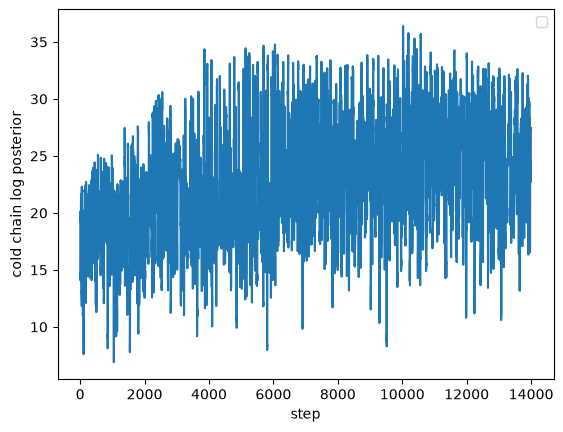

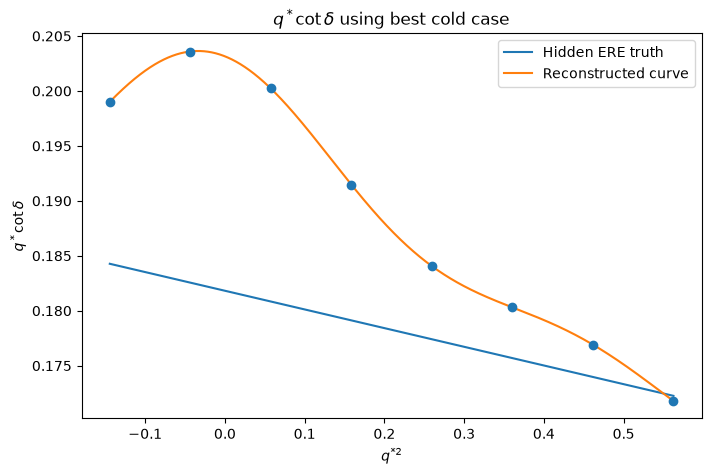

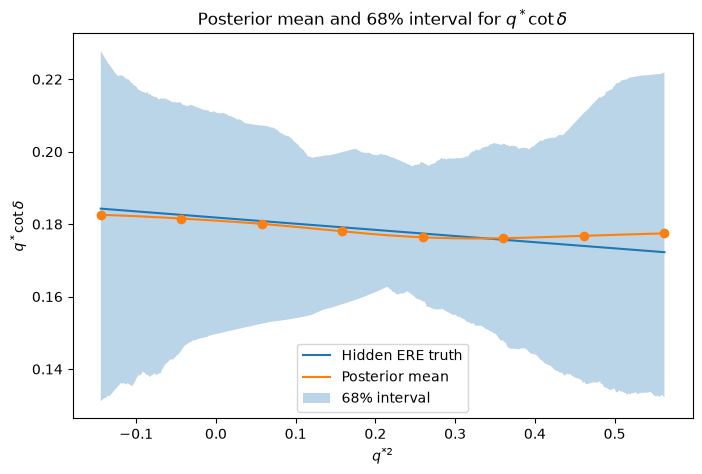

In [187]:
plot_mcmc(observed_cache_fake_data, best_cold_state_cov, cold_log_post_history_cov, samples_cov)

In [179]:
print(f"Best Chi Squared: {best_cold_chi_squared}")


Best Chi Squared: 0.07932264091409096


In [180]:
swap_rates = swap_accepts_cov/swap_attempts_cov
for i, rate in enumerate(swap_rates):
    print(f"({betas[i]:.3f}, {betas[i+1]:.3f}): {rate:.4f}")

(0.000, 0.040): 0.2573
(0.040, 0.080): 0.2520
(0.080, 0.150): 0.6413
(0.150, 0.250): 0.6653
(0.250, 0.320): 0.8107
(0.320, 0.450): 0.7300
(0.450, 0.500): 0.9213
(0.500, 0.540): 0.9340
(0.540, 0.580): 0.9360
(0.580, 0.610): 0.9507
(0.610, 0.650): 0.9540
(0.650, 0.680): 0.9653
(0.680, 0.710): 0.9633
(0.710, 0.760): 0.9453
(0.760, 0.800): 0.9600
(0.800, 0.850): 0.9473
(0.850, 0.880): 0.9767
(0.880, 0.930): 0.9600
(0.930, 0.950): 0.9773
(0.950, 1.000): 0.9620


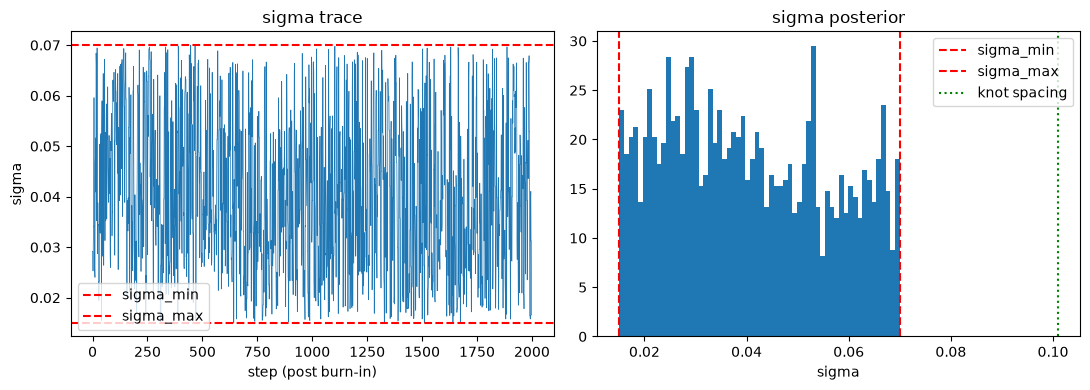

sigma posterior: median=0.03885, 16-84%=[0.02310, 0.05974]
bounds: sigma_min=0.015, sigma_max=0.07, knot_spacing=0.10098
fraction of samples within 5% of sigma_min: 1.15%


In [181]:
import matplotlib.pyplot as plt

# 1. No need to slice out burn-in, the tempering function already discarded it.
# 2. Extract the length_scale (index 2) from the 4-tuple (f_values, sigma, length_scale, mu)
sigma_chain = [state[1] for state in samples_cov]

fig, axs = plt.subplots(1, 2, figsize=(11, 4))

# left: trace, so you can see if it's still wandering or has settled
axs[0].plot(sigma_chain, lw=0.5)
axs[0].axhline(sigma_min, color='r', ls='--', label='sigma_min')
axs[0].axhline(sigma_max, color='r', ls='--', label='sigma_max')
axs[0].set_xlabel('step (post burn-in)')
axs[0].set_ylabel('sigma')
axs[0].legend()
axs[0].set_title('sigma trace')

# right: marginal posterior vs the bounds
axs[1].hist(sigma_chain, bins=60, density=True)
axs[1].axvline(sigma_min, color='r', ls='--', label='sigma_min')
axs[1].axvline(sigma_max, color='r', ls='--', label='sigma_max')
axs[1].axvline(knot_spacing, color='g', ls=':', label='knot spacing')
axs[1].set_xlabel('sigma')
axs[1].set_title('sigma posterior')
axs[1].legend()

plt.tight_layout()
plt.show()

# length_scale_chain is now a standard list, convert to numpy array for the math operations
sigma_chain = np.array(sigma_chain)

print(f"sigma posterior: median={np.median(sigma_chain):.5f}, "
      f"16-84%=[{np.percentile(sigma_chain,16):.5f}, {np.percentile(sigma_chain,84):.5f}]")
print(f"bounds: sigma_min={sigma_min}, sigma_max={sigma_max}, knot_spacing={knot_spacing:.5f}")
print(f"fraction of samples within 5% of sigma_min: {(sigma_chain < sigma_min*1.05).mean():.2%}")

In [182]:
def chi2_ar(params, channel_data):
    a, r = params
    p4 = 0.0
    L = channel_data["L"]
    sector_keys = channel_data["sector_keys"]
    obs = channel_data["obs"]
    cov_inv = channel_data["cov_inv"]

    needed_Psq = sorted(set(psq for psq, _ in sector_keys))
    pred_by_sector = {}
    for Psq in needed_Psq:
        Q = quantization_grid(a, r, p4, L, Psq)
        poles = free_particle_poles_cached(Psq_to_nP[Psq], L, m, E_min, E_max)
        zeros = np.sort(find_zeros_in_grid(Q, Ecm_grid, poles, Psq))
        pred_by_sector[Psq] = (zeros / 2)**2 - m**2   # convert once, up front

    pred = np.empty_like(obs)
    for i, (Psq, level_index) in enumerate(sector_keys):
        q2_pred_arr = pred_by_sector[Psq]
        if level_index >= len(q2_pred_arr):
            return 1e6   # not enough predicted levels in this sector
        pred[i] = q2_pred_arr[level_index]

    delta = pred - obs
    return delta @ cov_inv @ delta


In [183]:
def diagnose_chi2_ar(a, r, channel_data, p4=0.0, verbose=True):
    L = channel_data["L"]
    sector_keys = channel_data["sector_keys"]

    needed_by_sector = {}
    for psq, level_index in sector_keys:
        needed_by_sector[psq] = max(needed_by_sector.get(psq, 0), level_index + 1)

    for Psq, n_needed in sorted(needed_by_sector.items()):
        Q = quantization_grid(a, r, p4, L, Psq)
        poles = free_particle_poles_cached(Psq_to_nP[Psq], L, m, E_min, E_max)
        zeros = np.sort(find_zeros_in_grid(Q, Ecm_grid, poles, Psq))
        status = "OK" if len(zeros) >= n_needed else "SHORT"
        if verbose:
            print(f"Psq={Psq}: need {n_needed}, found {len(zeros)}  [{status}]  zeros={zeros}")



In [184]:
def M_using_c(Ecm, c0, c1, c2):
    s = Ecm**2
    qcm = q_cm_vectorized(s)
    effective_range = c0 + c1*(qcm**2) + c2*(qcm**4)
    return (8.0*np.pi*np.sqrt(s)) / (xi*(effective_range - 1j*qcm))

def quantization_grid_c(c0, c1, c2, L, Psq_tot):
    M_values = M_using_c(Ecm_grid, c0, c1, c2)
    F_values = F_by_Psq[(L, Psq_tot)]
    return np.real(1.0/M_values + F_values)

def chi2_c(params, channel_data):
    c0, c1 = params
    c2 = 0.0
    L = channel_data["L"]
    sector_keys = channel_data["sector_keys"]
    obs = channel_data["obs"]
    cov_inv = channel_data["cov_inv"]

    needed_Psq = sorted(set(psq for psq, _ in sector_keys))
    pred_by_sector = {}
    for Psq in needed_Psq:
        Q = quantization_grid_c(c0,c1,c2, L, Psq)
        poles = free_particle_poles_cached(Psq_to_nP[Psq], L, m, E_min, E_max)
        zeros = np.sort(find_zeros_in_grid(Q, Ecm_grid, poles, Psq))
        pred_by_sector[Psq] = (zeros / 2)**2 - m**2   # convert once, up front

    pred = np.empty_like(obs)
    for i, (Psq, level_index) in enumerate(sector_keys):
        q2_pred_arr = pred_by_sector[Psq]
        if level_index >= len(q2_pred_arr):
            return 1e6   # not enough predicted levels in this sector
        pred[i] = q2_pred_arr[level_index]

    delta = pred - obs
    return delta @ cov_inv @ delta
    # identical body to chi2_ar, but call quantization_grid_c(c0, c1, c2, L, Psq)

In [185]:
from scipy.optimize import minimize
diagnose_chi2_ar(-5.50, -0.034, observed_cache_dineutron)
result = minimize(chi2_c, x0=[0.182, -0.017], args=(observed_cache_dineutron,), method="Nelder-Mead")
print(result.x, result.fun)

NameError: name 'observed_cache_dineutron' is not defined

In [ ]:
best_f_knots, best_sigma, best_length_scale = best_cold_state_cov
print(best_f_knots)
print(best_sigma, sigma_max)   # is best_sigma pinned near the upper bound?

ValueError: too many values to unpack (expected 3, got 4)